# 抖音电商平台新人礼券使用率优化策略

## 业务背景
 
### 抖音电商为吸引新用户下单，会给未在商城下单的新用户发放新人礼券，新用户进入商城页面时，会弹出优惠券的页面，新用户自动领取到优惠券，优惠券有以下两种类型：

### 1）无门槛优惠券（10元）
### 2）折扣券（6折最高减10元）

### 因为营销预算受限，两类优惠券会随机发放给新用户，无门槛优惠券给30%的用户发放，折扣券给70%的用户发放，优惠券的有效期为24小时，未使用的优惠券到期后会自动失效，无法再次领取。

### 现在营销预算进一步缩减，运营人员考虑调整投放策略。

### 数据：
- **User_id**：用户ID  
- **IP_city**：IP所在城市  
- **Phone_os**：手机系统  
- **Register_date**：注册日期  
- **Is_live_tip**：是否直播打赏，领券前是否在直播间打赏，有打赏记录记为1，无记为0  
- **Live_hour**：浏览直播时长，领券前浏览直播的时长  
- **Video_hour**：浏览短视频时长，领券前浏览短视频的时长  
- **Coupon_date**：领券日期  
- **Coupon_type**：券类型  
- **Coupon_detail**：券明细  
- **Order_date**：用券日期  
- **Order_amount**：用券订单金额  
- **Order_discount_amount**：优惠金额，使用优惠券的折扣金额  


In [1]:
import pandas as pd

df = pd.read_csv('/Users/qianhonglin/Desktop/Data Analyst/Project 1 抖音电商平台新人礼券使用率优化策略/data/coupon_data.csv')
print(df.columns)
df

Index(['User_id', 'IP_city', 'Phone_os', 'Register_date', 'Is_live_tip',
       'Live_hour', 'Video_hour', 'Coupon_date', 'Coupon_type',
       'Coupon_detail', 'Order_date', 'Order_amount', 'Order_discount_amount'],
      dtype='object')


,User_id,IP_city,Phone_os,Register_date,Is_live_tip,Live_hour,Video_hour,Coupon_date,Coupon_type,Coupon_detail,Order_date,Order_amount,Order_discount_amount
0,100000,北京,android,2023/7/7,0,16,763,2024/7/1,无门槛优惠券,10元无门槛优惠券,NaN,NaN,NaN
1,100001,深圳,android,2023/7/7,0,0,681,2024/7/1,折扣券,6折券（最高减10）,NaN,NaN,NaN
2,100002,深圳,android,2023/7/7,0,0,501,2024/7/1,折扣券,6折券（最高减10）,NaN,NaN,NaN
3,100003,广州,IOS,2023/7/7,0,13,1080,2024/7/1,折扣券,6折券（最高减10）,NaN,NaN,NaN
4,100004,上海,IOS,2023/7/7,0,50,522,2024/7/1,折扣券,6折券（最高减10）,2024/7/1,18.0,7.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
647117,747117,广州,IOS,2024/9/30,0,0,3,2024/9/30,折扣券,6折券（最高减10）,NaN,NaN,NaN
647118,747118,北京,android,2024/9/30,0,0,1,2024/9/30,折扣券,6折券（最高减10）,NaN,NaN,NaN
647119,747119,上海,IOS,2024/9/30,0,0,1,2024/9/30,折扣券,6折券（最高减10）,NaN,NaN,NaN
647120,747120,深圳,android,2024/9/30,0,0,1,2024/9/30,无门槛优惠券,10元无门槛优惠券,2024/9/30,11.0,10.0


# 第一步：折扣券的人均营销成本是否低于无门槛优惠券？

## 1. 无门槛优惠券（10 元）  
- 发券成本固定：  
  $Cost_{\text{无门槛}} = 10\text{ 元}$

## 2. 6折封顶10 元券  
- 对第 $i$ 位领券用户，设其下单金额为 $order\_amount_i$：  
  $$
    Discount_i =
    \begin{cases}
      \min\bigl(order\_amount_i \times (1 - 0.6),\,10\bigr), & order\_amount_i > 0,\\
      0, & order\_amount_i = 0
    \end{cases}
  $$

- *实际使用优惠券* $N$ 位领券用户的人均营销成本：  
  $$
    Cost_{\text{6折封顶}}
    = \frac{1}{N}\sum_{i=1}^{N} Discount_i
  $$

## 3. 成本对比判断  
- 若  
  $$
    Cost_{\text{6折封顶}} < Cost_{\text{无门槛}} = 10\text{ 元}
  $$  
  则说明 **6折封顶10 元券** 的人均营销成本更低；  
- 否则，则 **无门槛优惠券** 的人均营销成本更低或相等。  


In [2]:
# 定义计算每位用户实际营销成本的函数
def calc_cost(row):
    if row['Coupon_type'] == '无门槛优惠券':
        return 10.0
    elif row['Coupon_type'] == '折扣券':
        amt = row.get('Order_amount', 0) or 0
        return min(amt * (1 - 0.6), 10.0) if amt > 0 else 0.0

# 计算成本列
df['cost'] = df.apply(calc_cost, axis=1)


# 统计各类型券的人均成本

# 先过滤：只保留已使用（有下单日期）的优惠券
used_df = df[pd.notnull(df['Order_date'])]

avg_cost = (
    used_df.groupby('Coupon_type')['cost']
      .mean()
      .reset_index()
      .rename(columns={'cost': 'avg_cost'})
)


avg_cost


,Coupon_type,avg_cost
0,折扣券,6.914111
1,无门槛优惠券,10.000000


In [3]:
from statsmodels.stats.weightstats import ztest

# 使用优惠券的人 cost 列
disc  = used_df.loc[used_df['Coupon_type'] == '折扣券', 'cost'].dropna().to_numpy()
nothr = used_df.loc[used_df['Coupon_type'] == '无门槛优惠券', 'cost'].dropna().to_numpy()


# 双尾 z 检验
# H0：两组均值相等 μ_disc = μ_nothr
# H1：两组均值不相等 μ_disc ≠ μ_nothr
z_twoside, p_twoside = ztest(
    disc,           # 样本1：折扣券用户成本
    nothr,          # 样本2：无门槛券用户成本
    value=0,        # 假设的均值差（这里是0，表示假设两组均值相等）
    alternative='two-sided'  # 双尾检验，检验“是否有差异”，不关心方向
)

print(f"\n双尾 z 检验: z={z_twoside}, p={p_twoside}")


# 单尾 z 检验
# H0：折扣券成本 ≥ 无门槛券成本 μ_disc >= μ_nothr
# H1：折扣券成本 < 无门槛券成本 μ_disc < μ_nothr
z_left, p_left = ztest(
    disc,           # 样本1：折扣券用户成本
    nothr,          # 样本2：无门槛券用户成本
    value=0,        # 假设的均值差（0 表示假设两组均值相等）
    alternative='smaller'  # 单尾检验（左尾），检验“第一组 < 第二组”
)

print(f"单尾 z 检验(折扣<无门槛): z={z_left}, p={p_left}")

alpha = 0.05

# 双尾结论
if p_twoside < alpha:
    print(f"\n结论1 双尾: 在显著性水平 {alpha} 下，两种券的人均成本存在显著差异（p={p_twoside}）。")
else:
    print(f"\n结论1 双尾: 在显著性水平 {alpha} 下，未发现两种券的人均成本存在显著差异（p={p_twoside}）。")

# 单尾结论（“折扣券 < 无门槛券”）
if p_left < alpha:
    print(f"结论2 单尾: 折扣券人均成本显著低于无门槛券。")
else:
    print(f"结论2 单尾: 折扣券人均成本不显著低于无门槛券。")




双尾 z 检验: z=-155.10652365387426, p=0.0
单尾 z 检验(折扣<无门槛): z=-155.10652365387426, p=0.0

结论1 双尾: 在显著性水平 0.05 下，两种券的人均成本存在显著差异（p=0.0）。
结论2 单尾: 折扣券人均成本显著低于无门槛券。


# 第二步：如果折扣券的人均营销成本较低，是否存在一种用户，领券折扣券下单的概率大于或等于领券无门槛优惠券后下单的概率？

#### 聚类尝试

1. 对所有用户进行分类（如使用 K‑means 聚类，选取特征）: 利用轮廓系数判断$K$取值

2. 计算各类型用户的转化率：  
   $$
   \mathrm{ConvRate}_1(S)
   = 
   \frac{\bigl|\{\,i\in S:\text{下单且使用无门槛券}\}\bigr|}
        {\bigl|\{\,i\in S:\text{领取无门槛券}\}\bigr|}
   ,\qquad
   \mathrm{ConvRate}_2(S)
   = 
   \frac{\bigl|\{\,i\in S:\text{下单且使用折扣券}\}\bigr|}
        {\bigl|\{\,i\in S:\text{领取折扣券}\}\bigr|}
   $$

3. 筛选群体：  
   找出所有满足  
   $$
   \mathrm{ConvRate}_2(S)\;\ge\;\mathrm{ConvRate}_1(S)
   $$  
   的用户群体 $S$  

4. 显著性检验：  
   对比两组转化率差异，使用$Z$-检验，确保结论具有统计显著性  

#### 最后结果发现聚类选出来的组几乎是占了全部的数据，说明这个模型效果不好：这个主要原因是轮廓系数比较低，很难分出特征差异比较明显的群体。同时聚类很难得到比较具体的策略推荐规则，例如“特征值>一个阈值的用户适合什么策略”这种形式的规则。


## 方法：因果推断

### **为什么这里不能用DID 和 PSM：**

### 1、DID是需要有时间趋势，比如说领折扣券前后商家销售额，用户购买量改变了多少这种，才能用
### 2、PSM来说这不是“总体上折扣券效果是不是比无门槛券好”，而是“对于某些特定用户，折扣券效果 ≥ 无门槛券”。PSM 估的是“整体匹配后平均”效果，回答不了“哪类用户的个体化增益 Δ(X)比较”


In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from causalml.inference.tree import UpliftTreeClassifier
from causalml.metrics.visualize import plot_qini
from causalml.metrics import qini_score

Failed to import duecredit due to No module named 'duecredit'


### 步骤一：生成需要的变量和特征工程

1. **生成干预标签（treatment）**

   * 根据 `Coupon_type` 映射两种策略：

     * “无门槛优惠券” → `no_threshold`
     * “折扣券” → `discount`

2. **构造目标变量（y）**

   * 新增 `coupon_used_flag`：

     * 若 `Order_date` 不为空，则标记为 1（使用优惠券）
     * 否则为 0

3. **定义特征集**

   * **连续特征**

     * `register_to_coupon_days`、`days_to_order`
     * `Live_hour`、`Video_hour`
     * `Order_amount`、`Order_discount_amount`
   * **类别特征**

     * `Is_live_tip`、`IP_city`、`Phone_os`



In [5]:
csv_path = '/Users/qianhonglin/Desktop/Data Analyst/Project 1 抖音电商平台新人礼券使用率优化策略/data/coupon_data.csv'
Df = pd.read_csv(csv_path)

df = Df.copy()
for col in ['Register_date', 'Coupon_date', 'Order_date']:
    df[col] = pd.to_datetime(df[col], format='%Y/%m/%d', errors='coerce')

# 生成 treatment（用作某种干预t）
df['treatment'] = df['Coupon_type'].map({
    '无门槛优惠券': 'no_threshold',
    '折扣券':   'discount'
})

# 生成优惠券标识（目标变量y）
df['coupon_used_flag'] = df['Order_date'].notna().astype(int) # 是否使用了优惠券（0/1）


# print(df.columns)
# Index(['User_id', 'IP_city', 'Phone_os', 'Register_date', 'Is_live_tip',
#        'Live_hour', 'Video_hour', 'Coupon_date', 'Coupon_type',
#        'Coupon_detail', 'Order_date', 'Order_amount', 'Order_discount_amount',
#        'treatment'],


# 特征工程
df['register_to_coupon_days'] = (df['Coupon_date'] - df['Register_date']).dt.days.fillna(0) # 注册到领券的天数差
df['days_to_order']         = (df['Order_date'] - df['Coupon_date']).dt.days.fillna(0) # 领券到下单的天数
df['Live_hour']             = df['Live_hour'].fillna(0) # 直播观看时长（填 0 表示未看）
df['Video_hour']            = df['Video_hour'].fillna(0) # 短视频浏览时长（填 0 表示未看）
df['Order_amount']          = df['Order_amount'].fillna(0) # 下单金额（填 0 表示未下单）
df['Order_discount_amount'] = df['Order_discount_amount'].fillna(0) # 优惠金额（填 0 表示未使用优惠券）

df['Is_live_tip']           = df['Is_live_tip'].fillna(0) # 直播打赏标志（填 0/1）



# 预处理与划分
continuous_features = [
    'register_to_coupon_days', 
    'days_to_order',
    'Live_hour', 
    'Video_hour',
    'Order_amount', 
    'Order_discount_amount',
    ]
categorical_features = [
    'Is_live_tip',
    'IP_city', 
    'Phone_os'
]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), continuous_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])


### 步骤二：用因果树进行模型训练和预测


**关键变量解释**

- **`X`**  
  - 特征矩阵：包含对原始 DataFrame 中所有连续特征做标准化、类别特征做独热编码后的数值化特征，作为模型输入。

- **`treatment`**  
  - 干预组标签数组：每个元素是该样本对应的优惠券策略（`'no_threshold'` 或 `'discount'`），  
    用于告诉 uplift 模型哪部分样本属于“对照组”或“实验组”。

- **`y`**  
  - 目标变量数组：由 0/1 组成，表示该样本是否真正使用了优惠券（1 = “最高10元6折券”，0 = “无门槛券”），用于模型拟合和评估。



 **训练并预测并计算 uplift**  
   - 对测试集调用  
     ```python
     proba = ct.predict(X_test)
     ```  
     得到两列概率：  
     - `proba[:, 0]` = P(order=1 | no_threshold)  
     - `proba[:, 1]` = P(order=1 | discount)  
   - 计算增量：  
     ```python
     uplift_vals = proba[:, 1] - proba[:, 0]


In [6]:

X = preprocessor.fit_transform(df)
treatment = df['treatment'].values
y = df['coupon_used_flag'].values

X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(X, treatment, y, test_size=0.2, random_state=42)

# 训练与预测
ct = UpliftTreeClassifier(
    control_name='no_threshold',  # 指定对照组标签
    max_depth=5,                  # 限制树的最大深度为5
    min_samples_leaf=50,           # 每个叶节点上至少要有50个样本
    min_samples_treatment=30,      # 每叶最少实验组样本
    random_state=42,               # 固定随机种子
)


ct.fit(X_train, treatment=t_train, y=y_train)


#预测下单概率，计算 uplift
proba = ct.predict(X_test)

# proba[:, 0] = P(order=1 | 无门槛)
# proba[:, 1] = P(order=1 | 最大10折扣)

# uplift = P(折扣券) - P(无门槛券)
uplift_vals = proba[:, 1] - proba[:, 0]

result_df = pd.DataFrame({
    'P_no_threshold': proba[:, 0],     # 用户在“无门槛”组下被预测为下单（order=1）的概率（对照组预测概率）
    'P_discount':     proba[:, 1],     # 用户在“折扣”组下被预测为下单（order=1）的概率（试验组预测概率）
    'model_uplift':   uplift_vals,     # 模型预测的 uplift 值，即 P_discount - P_no_threshold，表示因干预带来的增量概率
    'treatment':      t_test,          # 测试集中每个样本的实际分组标签（'no_threshold' 或 'discount'）
    'actual_outcome': y_test           # 测试集中每个样本的真实结果（coupon_used_flag，0/1 表示是否使用了券）
})


# 映射 treatment 为 0/1
result_df['treatment_map'] = result_df['treatment'].map({'no_threshold': 0, 'discount': 1}).astype(int)

print(f"满足 model_uplift ≥ 0 的用户数：{(result_df['model_uplift'] >= 0).sum()} / {len(result_df)}")


满足 model_uplift ≥ 0 的用户数：77618 / 129425


### 步骤三：用Qini 曲线和Qini score进行模型评价

### Qini 曲线的意义

- **可视化模型增益分布**  ：Qini 曲线将模型预测的个体增量（uplift）按照大小排序后，展示在不同分位（Population Quantile）上真实累积增益（Cumulative Uplift）的变化。  
- **评估精准投放效果**  ：通过对比模型曲线与随机基线（Random Baseline）间的偏离程度，可以直观判断模型在前几分位上能否更精准地识别出高增益人群。  
- **辅助阈值决策**  ：曲线陡峭的区间（曲线远高于随机线）对应的是“高效区”，可据此确定营销预算或投放比例的最佳阈值。


### Qini Score 的意义

- **量化模型优劣**  ：Qini Score 是模型曲线与随机基线之间面积差的数值表示，面积越大说明模型在各分位累计增益越显著，效果越好。  
- **比较不同模型／策略**  ：在多个 uplift 模型或多种处理策略之间，以 Qini Score 高低作为直接对比依据，选出最优方案。  

<Figure size 3900x1800 with 0 Axes>

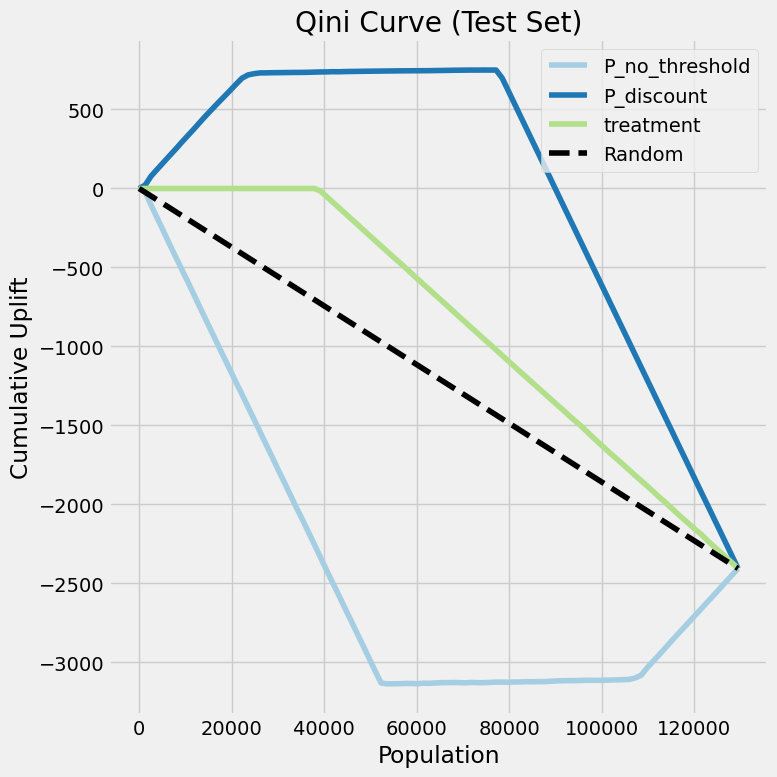

模型的 Qini score: P_no_threshold   -1219.643509
P_discount        1248.257985
treatment          358.690410
dtype: float64


In [7]:
# 画 Qini 曲线
plt.figure(figsize=(13, 6), dpi=300)

plot_qini(
    result_df,                            # DataFrame：包含实际结果、处理分组和模型预测提升值
    outcome_col='actual_outcome',         # str：实际观测结果列名，用于计算累积提升
    treatment_col='treatment_map',        # str：处理分组列名，指示哪些样本接受了处理
    treatment_effect_col='model_uplift',  # str：模型预测的个体提升效果列名
    normalize=False                       # bool：是否对累积提升值进行归一化；False 表示使用原始提升值
)
plt.title("Qini Curve (Test Set)")
plt.xlabel("Population")
plt.ylabel("Cumulative Uplift")
plt.tight_layout()
plt.show()

# 计算 Qini score
score = qini_score(
    result_df,
    outcome_col='actual_outcome',
    treatment_col='treatment_map',
    treatment_effect_col='model_uplift',
    normalize=False
)

print(f"模型的 Qini score: {score}")


* **P\_no\_threshold（浅蓝）**
  如果你把所有人都当作做了 “no threshold” 处理（并按模型对这个策略的预测效果给人排序），那么在每个分位累积的真实增益是多少。

* **P\_discount（深蓝）**
  如果你把所有人都当作做了 “discount” 处理（同样按模型预测效果排序），那么对应的累积增益曲线。

* **treatment（浅绿）**
  这是你数据里标记为 `treatment` 的那组人 （在训练好的模型条件下，按原本的treatment得到的累积增益情况），按模型预测效果排序后实际观测到的累积增益。

* **Random（黑虚线）**
  随机分配给处理的基线：把人随机分到 “处理” 里，累积增益应该是一条直线。


### 核心结论：原本我们的策略是随机投放“无门槛券”和“最高10元6折券”，现在通过uplift模型我们发现：在测试集投放“最高10元6折券优惠券”在前10%-20%的用户增大了累计收益（他们的下单概率变大）


# 第三步：如果存在上述类型的用户，用户特征是怎样的？

In [8]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor


# 分离数值 & OHE 特征
X_scaled      = preprocessor.transform(df)
n_num         = len(continuous_features)
X_num_scaled  = X_scaled[:, :n_num]
X_cat_ohe     = X_scaled[:, n_num:]

# 数值部分逆变换到“原始”尺度
# scaler        = preprocessor.named_transformers_['num']
X_num_orig    = preprocessor.named_transformers_['num'].inverse_transform(X_num_scaled)

# 横向拼接：原始数值 + OHE 数值（0/1）
X_rebuilt     = np.hstack([X_num_orig, X_cat_ohe])

# 构造特征名（原数值名 + OHE 名）
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names     = continuous_features + list(cat_feature_names)

df_repr       = pd.DataFrame(X_rebuilt, columns=feature_names)


# 全数据计算 uplift、生成 mask
proba         = ct.predict(X_scaled)                    # 或 ct.predict_proba
uplift_vals   = proba[:, 1] - proba[:, 0]
mask          = uplift_vals >= 0


result_df = pd.DataFrame({
    'P_no_threshold': proba[:, 0],
    'P_discount':     proba[:, 1],
    'model_uplift':   uplift_vals
})

print(f'满足 model_uplift ≥ 0 的用户数：' f'{(result_df["model_uplift"] >= 0).sum()} / {len(result_df)}')


满足 model_uplift ≥ 0 的用户数：388228 / 647122


|--- register_to_coupon_days <= 1.50
|   |--- Video_hour <= 7.50
|   |   |--- Live_hour <= 11.50
|   |   |   |--- class: False
|   |   |--- Live_hour >  11.50
|   |   |   |--- class: True
|   |--- Video_hour >  7.50
|   |   |--- class: True
|--- register_to_coupon_days >  1.50
|   |--- Video_hour <= 7.50
|   |   |--- register_to_coupon_days <= 4.50
|   |   |   |--- Live_hour <= 11.50
|   |   |   |   |--- class: False
|   |   |   |--- Live_hour >  11.50
|   |   |   |   |--- class: True
|   |   |--- register_to_coupon_days >  4.50
|   |   |   |--- class: True
|   |--- Video_hour >  7.50
|   |   |--- class: True



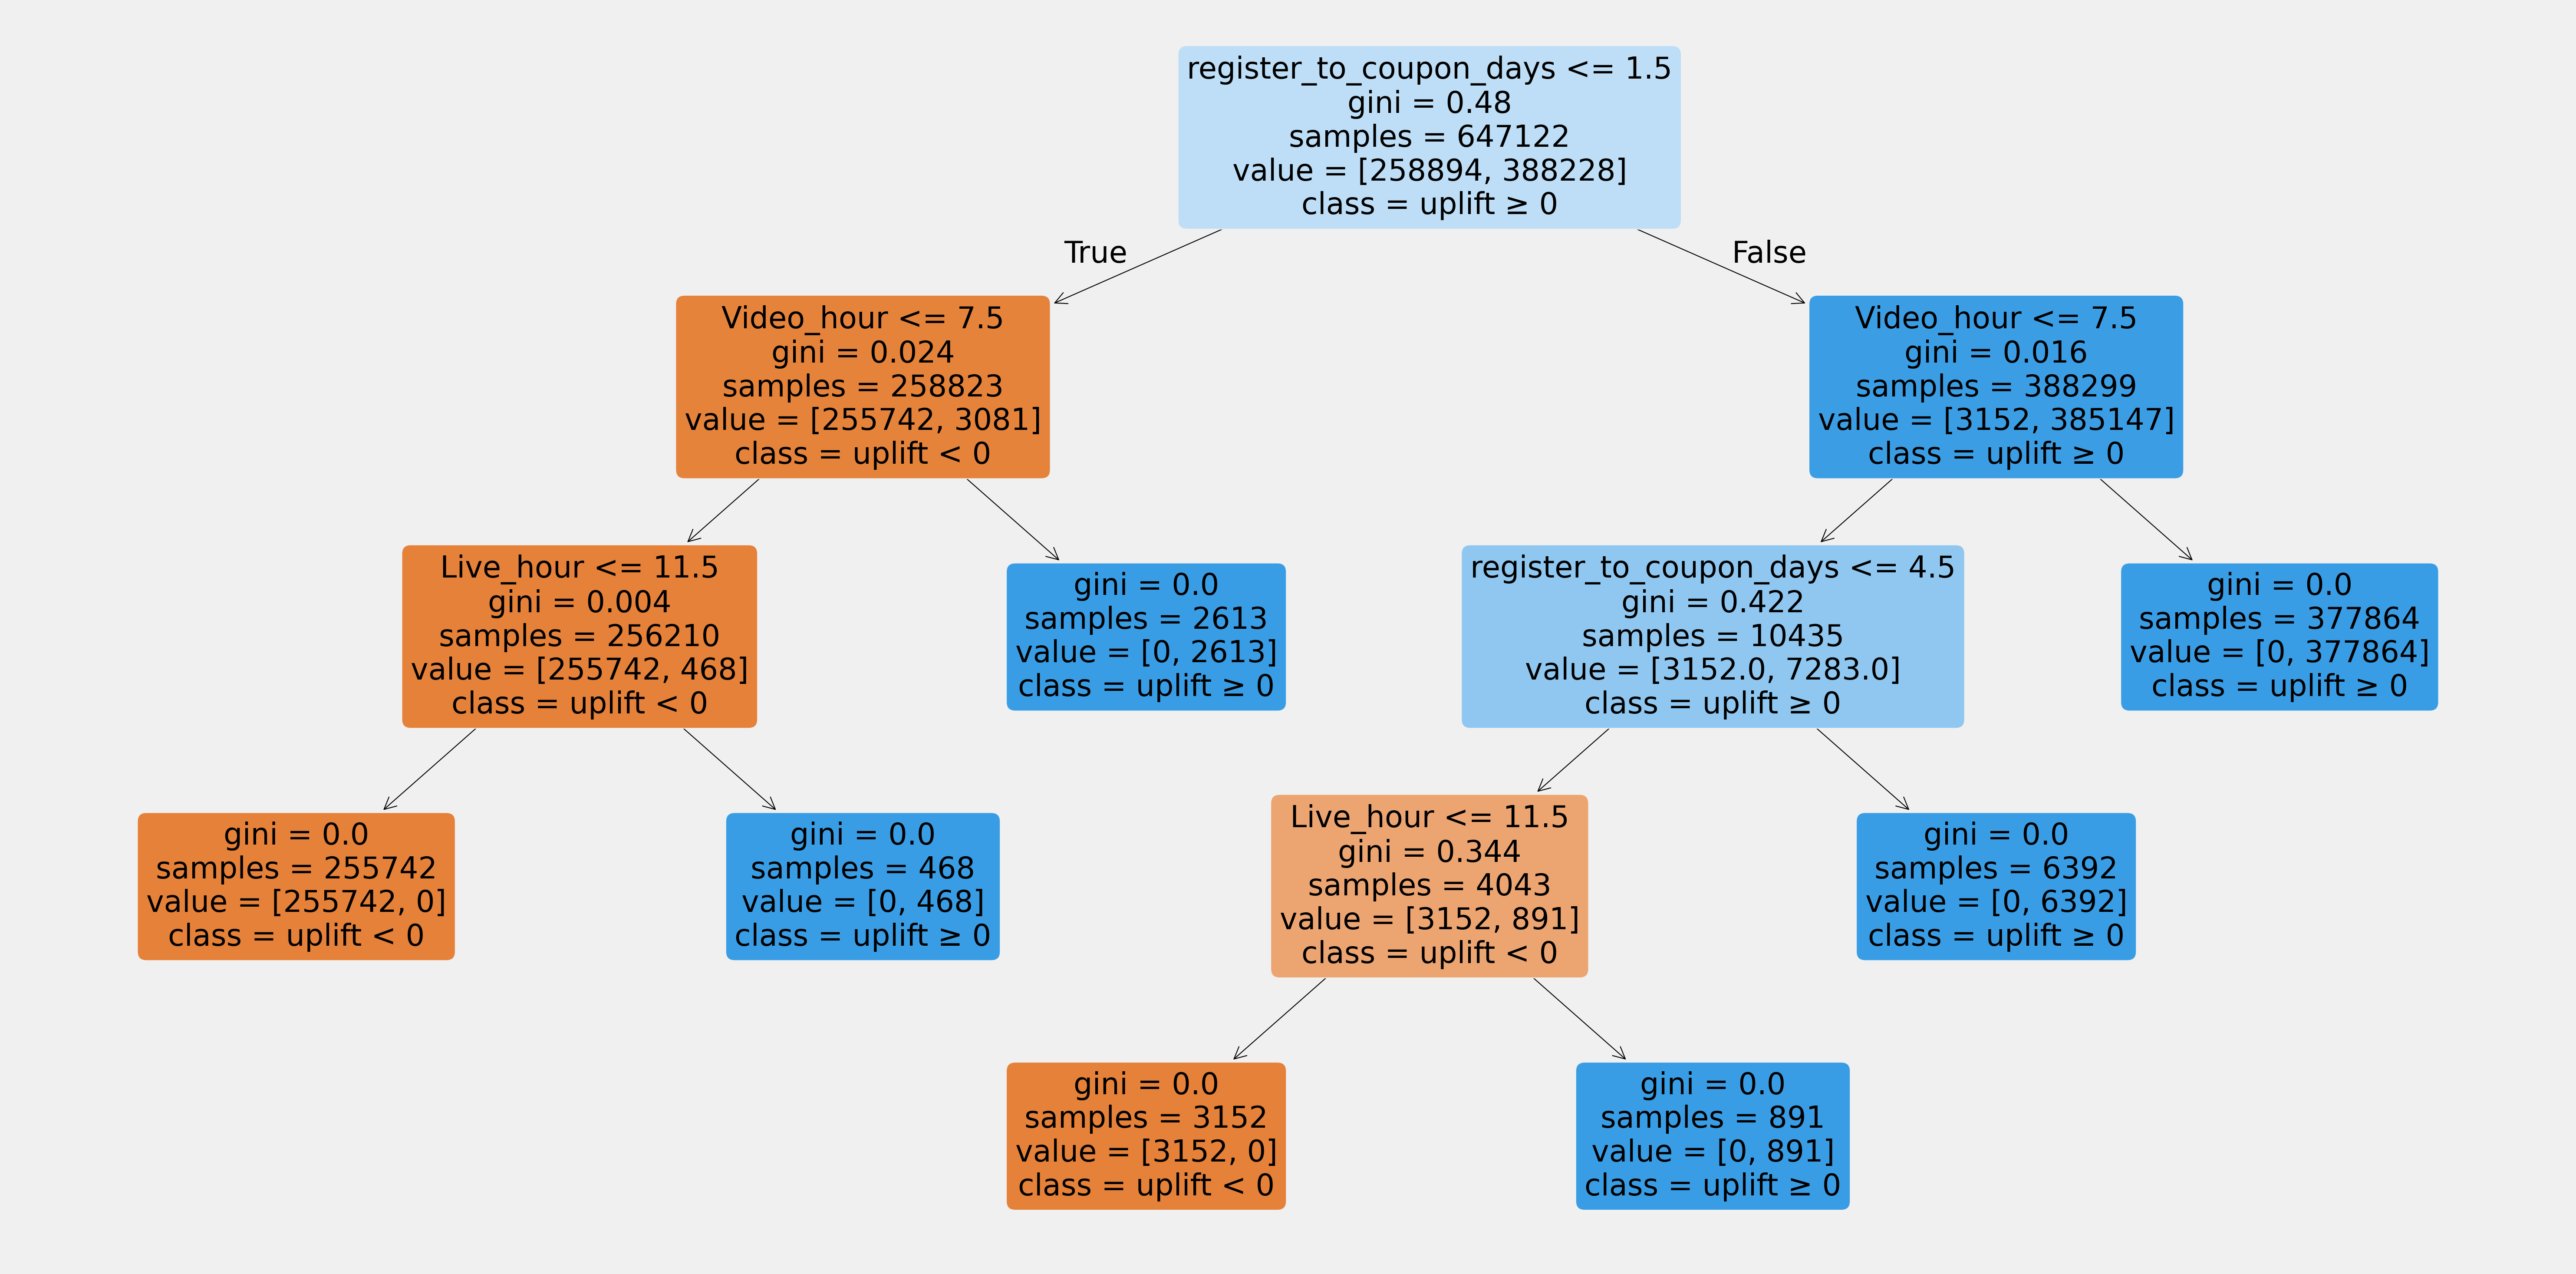

In [9]:
# 在“原始”特征上重训练决策树
rule_tree     = DecisionTreeClassifier(criterion="gini",
                                       max_depth=5, 
                                       min_samples_leaf=50)
rule_tree.fit(df_repr, mask)


print(export_text(rule_tree, feature_names=feature_names))

plt.figure(figsize=(20, 10), dpi = 300)
plot_tree(
    rule_tree,
    feature_names=feature_names,
    class_names=['uplift < 0', 'uplift ≥ 0'], # 顺序必须是 [0,1]
    filled=True,
    rounded=True
)

plt.tight_layout()
plt.show()

### 用户类型结论

### 1. 快速领券 + 内容活跃型

- **注册→领券间隔**  
  - `register_to_coupon_days` ≤ 1.5 说明：注册后非常快就领券。
- **再分两支**：
  1. **视频活跃**  
     - `Video_hour` > 7.5
     - **强烈正响应**
  2. **视频不活跃 但 直播活跃**  
     - `Video_hour` ≤ 7.5 
     - `Live_hour` > 11.5
     - **正响应**


### 2. 慢速领券 + 视频活跃型

- **注册→领券间隔**  
  - `register_to_coupon_days` > 1.5 （“较慢”或“中等”节奏）
- **视频活跃**  
  - `Video_hour` > 7.5
  - **无论直播状况，都是正向增效**


### 3. 慢速领券 + “成熟订阅”型

- **注册→领券间隔**  
  - `register_to_coupon_days`  >1.5
- **视频不活跃**  
  - `Video_hour` ≤ 7.5
- **从容领券**  
  - `register_to_coupon_days` > 4.5（更晚领取）  
  - **正响应**  
  - 说明：不怎么看视频，但慢领券表明他们更有耐心、更价格敏感，6折券能显著驱动下单。


### 4. 缓冲领券 + 直播主导型

- **注册→领券间隔**  
  - `register_to_coupon_days` 在 [1.5, 4.5]
- **视频不活跃**  
  - `Video_hour` ≤ 7.5
- **直播活跃**  
  - `Live_hour` > 11.5
  - **正响应**


### 营销建议

- **优先触达：**
  - 对视频或直播至少一端较活跃的用户，或者领券节奏偏“从容”而非“一领就走”的用户
- **避免浪费：**
  - 视频和直播都不活跃且领券节奏极快的用户
